In [1]:
from google.colab import files

uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India.csv


Dataset Shape: (740, 7)

Column Names:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

Missing Values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Basic Statistics:
                                Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00                         8.350000   
75%              20

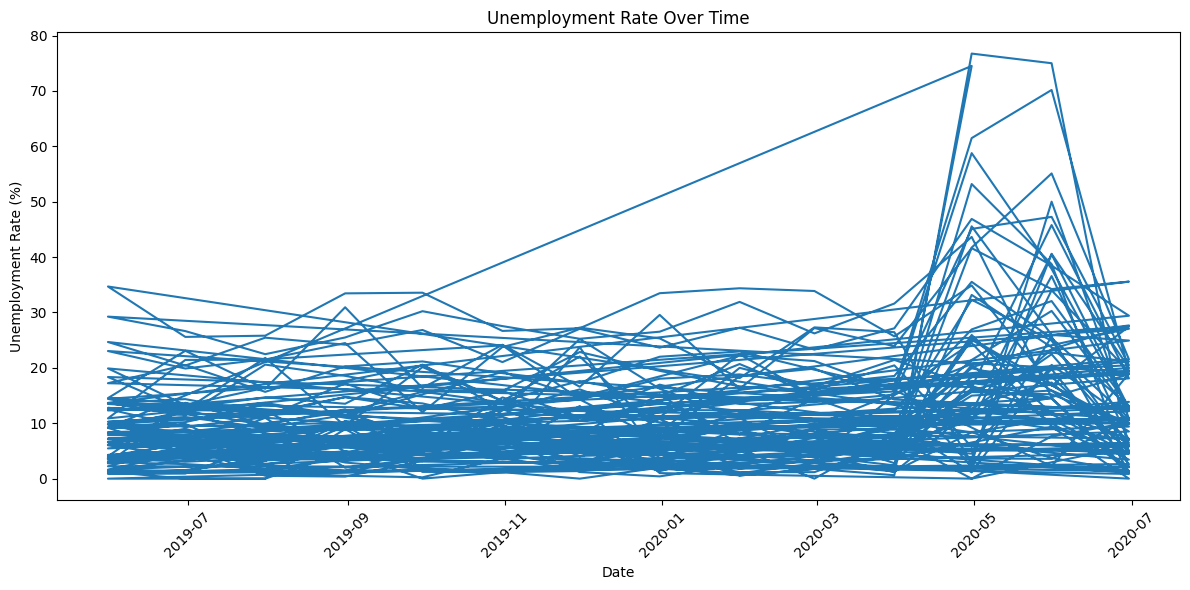


COVID-19 Analysis
Before COVID Average: 9.509533582089553
During COVID Average: 17.774362745098042

Monthly Average Unemployment:
Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64


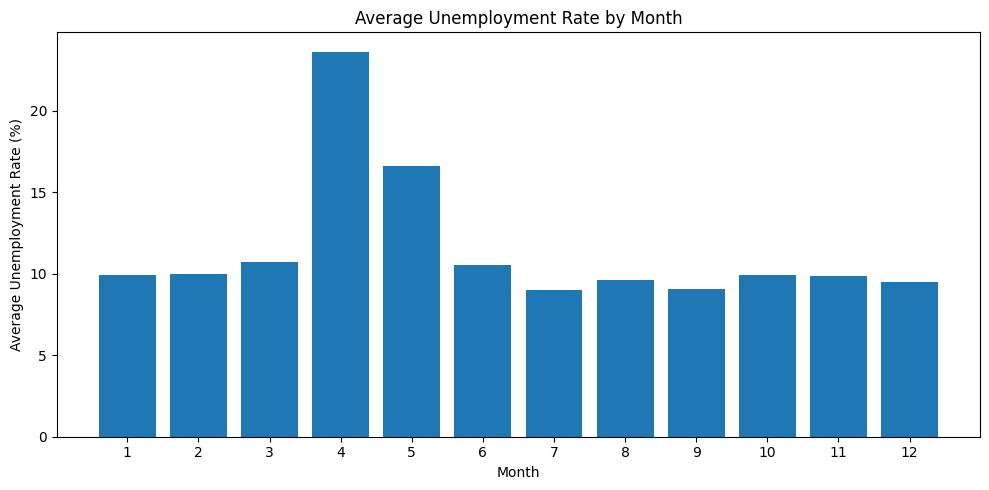

In [27]:
# ==========================================
# TASK 2: UNEMPLOYMENT ANALYSIS WITH PYTHON
# ==========================================

# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# 2. Load dataset
df = pd.read_csv("Unemployment in India.csv")

# 3. Remove extra spaces from column names
df.columns = df.columns.str.strip()

# 4. Remove completely empty rows
df = df.dropna(how='all')

# 5. Convert Date into datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# 6. Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

# 7. Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# 8. Basic statistics
print("\nBasic Statistics:")
print(df.describe())

# ==========================================
# 9. Unemployment Rate Analysis
# ==========================================

print("\nAverage Unemployment Rate:",
      df['Estimated Unemployment Rate (%)'].mean())

print("Maximum Unemployment Rate:",
      df['Estimated Unemployment Rate (%)'].max())

print("Minimum Unemployment Rate:",
      df['Estimated Unemployment Rate (%)'].min())

# ==========================================
# 10. Unemployment Trend Graph
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    df['Date'],
    df['Estimated Unemployment Rate (%)']
)

plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# 11. COVID-19 Analysis
# ==========================================

before_covid = df[
    df['Date'] < '2020-03-01'
]

during_covid = df[
    (df['Date'] >= '2020-03-01') &
    (df['Date'] <= '2020-12-31')
]

before_avg = before_covid[
    'Estimated Unemployment Rate (%)'
].mean()

during_avg = during_covid[
    'Estimated Unemployment Rate (%)'
].mean()

print("\nCOVID-19 Analysis")
print("Before COVID Average:", before_avg)
print("During COVID Average:", during_avg)

# ==========================================
# 12. Monthly / Seasonal Analysis
# ==========================================

df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')[
    'Estimated Unemployment Rate (%)'
].mean()

print("\nMonthly Average Unemployment:")
print(monthly_avg)

# ==========================================
# 13. Monthly Graph
# ==========================================

plt.figure(figsize=(10, 5))

plt.bar(
    monthly_avg.index,
    monthly_avg.values
)

plt.title('Average Unemployment Rate by Month')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()